# GENIS — Committee Evaluation

This notebook is dedicated exclusively to the committee experiment for the
GENIS dataset.

It consumes the committee artifacts already produced by `pipeline/committee.py`
and presents their configuration, validation-derived weights, final test
performance, comparison with the persisted individual classifiers, model
diversity/complementarity, and committee correction behavior.

No model is trained, refit, tuned, or re-evaluated in this notebook.


## Committee protocol

The GENIS committee is composed, for each persisted seed, of the three
selected component classifiers:

- Decision Tree
- Random Forest
- XGBoost

Four predefined aggregation strategies are evaluated:

- Hard Voting
- Weighted Hard Voting
- Soft Voting
- Weighted Soft Voting

For the weighted strategies, the weights are fixed for the dataset and are
derived exclusively from validation Macro F1 of the already-selected
classifier configurations. The frozen test labels are used only for final
committee metric calculation.

The committee experiment must already have been executed with:

```text
python -m pipeline.committee --dataset GENIS
```


## Report contents

This notebook reports only committee-related results:

1. committee configuration and validation-derived weights;
2. committee test performance aggregated across the three fixed seeds;
3. individual classifiers versus committee strategies, to contextualize the
   committee results against their component models;
4. a primary Macro F1 comparison figure;
5. pairwise model diversity and complementarity;
6. a prediction-disagreement heatmap; and
7. committee correction behavior.

No seed-level rows are displayed in the main result tables; the reported
statistics are aggregated as mean ± standard deviation across the persisted
seeds.


In [1]:
import matplotlib.pyplot as plt

from reporting.committee import (
    DEFAULT_ARTIFACTS_DIRECTORY,
    METRIC_DISPLAY_NAMES,
    PRIMARY_COMMITTEE_METRIC,
    CommitteeExperimentArtifacts,
    CommitteeStatistics,
    compile_committee_statistics,
    display_committee_statistics,
    load_committee_experiment_artifacts,
    plot_committee_prediction_disagreement_heatmap,
    plot_committee_primary_metric,
)

In [2]:
# ============================================================================
# Configuration
# ============================================================================

ARTIFACTS_DIRECTORY = DEFAULT_ARTIFACTS_DIRECTORY
DATASET_NAME = "GENIS"

## Load the persisted committee experiment

The reporting layer validates the committee artifact set, including dataset
identity, component classifiers, strategy definitions, seed consistency,
weight provenance, weight normalization, and summary consistency.


In [3]:
# ============================================================================
# Load and validate GENIS committee artifacts
# ============================================================================

GENIS_committee_artifacts: CommitteeExperimentArtifacts = (
    load_committee_experiment_artifacts(
        dataset_name=DATASET_NAME,
        artifacts_directory=ARTIFACTS_DIRECTORY,
    )
)

GENIS_committee_statistics: CommitteeStatistics = compile_committee_statistics(
    artifacts=GENIS_committee_artifacts,
    include_individual_comparison=True,
    artifacts_directory=ARTIFACTS_DIRECTORY,
)

## Committee configuration

The following table shows the selected configuration ID of each component
classifier, its validation Macro F1, and the resulting fixed committee
weight. The weights are not derived from the frozen test set.


In [4]:
# ============================================================================
# Committee configuration and validation-derived weights
# ============================================================================

display_committee_statistics(
    GENIS_committee_statistics,
    show_configuration=True,
    show_performance=False,
    show_comparison=False,
)

,Classifier,Configuration ID,Validation Macro F1,Committee weight
0,Decision Tree,1cbc00d06004,0.99983658,0.33331634
1,Random Forest,7eb62a443ff7,0.99992827,0.33334691
2,XGBoost,17edbfb766e1,0.99989776,0.33333674


## Committee test performance

The four predefined strategies are reported using mean ± standard deviation
across the three persisted seeds.


In [5]:
# ============================================================================
# Committee performance
# ============================================================================

display_committee_statistics(
    GENIS_committee_statistics,
    show_configuration=False,
    show_performance=True,
    show_comparison=False,
)

,Strategy,Seeds,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,Hard Voting,3,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000
1,Weighted Hard Voting,3,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000
2,Soft Voting,3,0.99999548 ± 0.00000783,0.99999859 ± 0.00000244,0.99998465 ± 0.00002658,0.99999162 ± 0.00001451,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,0.99998682 ± 0.00002283,0.99998465 ± 0.00002658
3,Weighted Soft Voting,3,0.99999548 ± 0.00000783,0.99999859 ± 0.00000244,0.99998465 ± 0.00002658,0.99999162 ± 0.00001451,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,0.99998682 ± 0.00002283,0.99998465 ± 0.00002658


## Component classifiers versus committee strategies

This comparison is included only to contextualize the committee experiment:
the individual-classifier values are loaded from their already-persisted
frozen-test evaluation artifacts, while the committee values come from the
committee artifacts.

No new classifier evaluation is performed here.


In [6]:
# ============================================================================
# Individual classifiers versus committee strategies
# ============================================================================

display_committee_statistics(
    GENIS_committee_statistics,
    show_configuration=False,
    show_performance=False,
    show_comparison=True,
)

,Method,Type,Seeds,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,Decision Tree,Individual classifier,3,0.99995478 ± 0.00002072,0.99986054 ± 0.00004814,0.99988519 ± 0.00003650,0.99987284 ± 0.00003942,0.99993425 ± 0.00002198,0.99975705 ± 0.00007427,0.99986820 ± 0.00006040,0.99988519 ± 0.00003650
1,Random Forest,Individual classifier,3,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000
2,XGBoost,Individual classifier,3,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000
3,Hard Voting,Committee,3,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000
4,Weighted Hard Voting,Committee,3,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000
5,Soft Voting,Committee,3,0.99999548 ± 0.00000783,0.99999859 ± 0.00000244,0.99998465 ± 0.00002658,0.99999162 ± 0.00001451,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,0.99998682 ± 0.00002283,0.99998465 ± 0.00002658
6,Weighted Soft Voting,Committee,3,0.99999548 ± 0.00000783,0.99999859 ± 0.00000244,0.99998465 ± 0.00002658,0.99999162 ± 0.00001451,1.00000000 ± 0.00000000,1.00000000 ± 0.00000000,0.99998682 ± 0.00002283,0.99998465 ± 0.00002658


## Primary metric comparison

Macro F1 is the predefined primary metric for the classifier and committee
experiments. The plot compares the three component classifiers with the four
committee strategies using the same persisted test-seed aggregation.


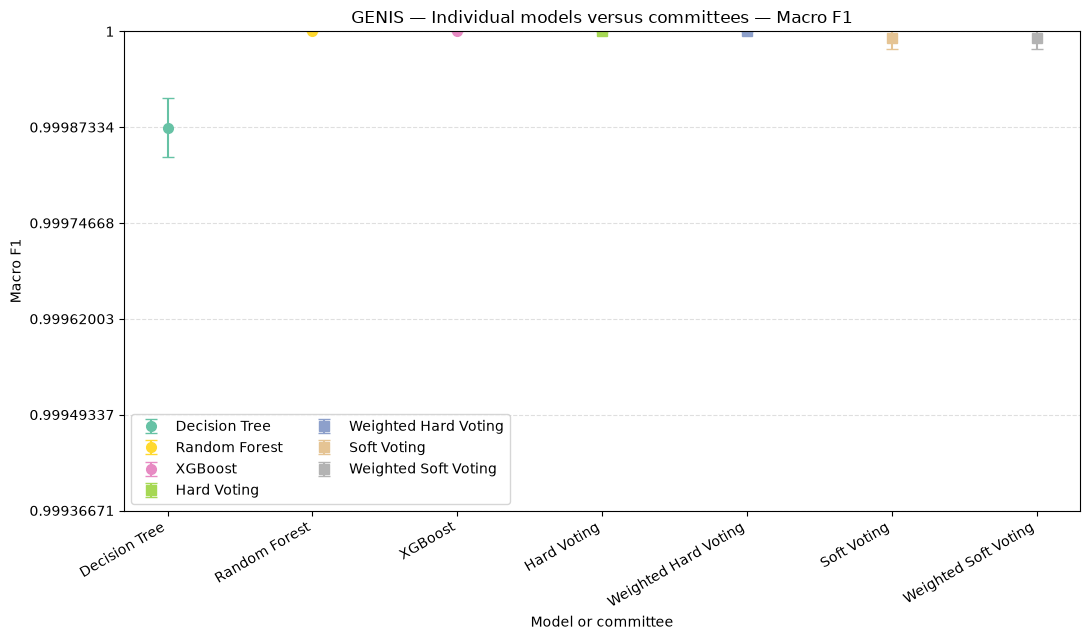

In [7]:
# ============================================================================
# Individual models versus committees — Macro F1
# ============================================================================

figure = plot_committee_primary_metric(
    comparison_table=GENIS_committee_statistics.comparison_table,
    metric=PRIMARY_COMMITTEE_METRIC,
    title=(
        f"{DATASET_NAME} — Individual models versus committees — "
        f"{METRIC_DISPLAY_NAMES[PRIMARY_COMMITTEE_METRIC]}"
    ),
)

display(figure)
plt.close(figure)

## Pairwise model diversity and complementarity

The persisted statistics quantify prediction disagreement, joint errors
through Double Fault, and overlap between the component classifiers
error sets. The displayed values are aggregated as mean ± standard
deviation across the persisted seeds.


In [8]:
# ============================================================================
# Pairwise model diversity and complementarity
# ============================================================================

display_committee_statistics(
    GENIS_committee_statistics,
    show_configuration=False,
    show_performance=False,
    show_comparison=False,
    show_diversity=True,
    show_correction=False,
)


,Classifier A,Classifier B,Prediction disagreement,Double Fault,Error-set Jaccard overlap
0,Decision Tree,Random Forest,0.00005 ± 0.00002,0.00000 ± 0.00000,0.00000 ± 0.00000
1,Decision Tree,XGBoost,0.00005 ± 0.00002,0.00000 ± 0.00000,0.00000 ± 0.00000
2,Random Forest,XGBoost,0.00000 ± 0.00000,0.00000 ± 0.00000,1.00000 ± 0.00000


## Prediction disagreement heatmap

The heatmap visualizes the mean prediction-disagreement rate for each
pair of component classifiers across the persisted seeds.


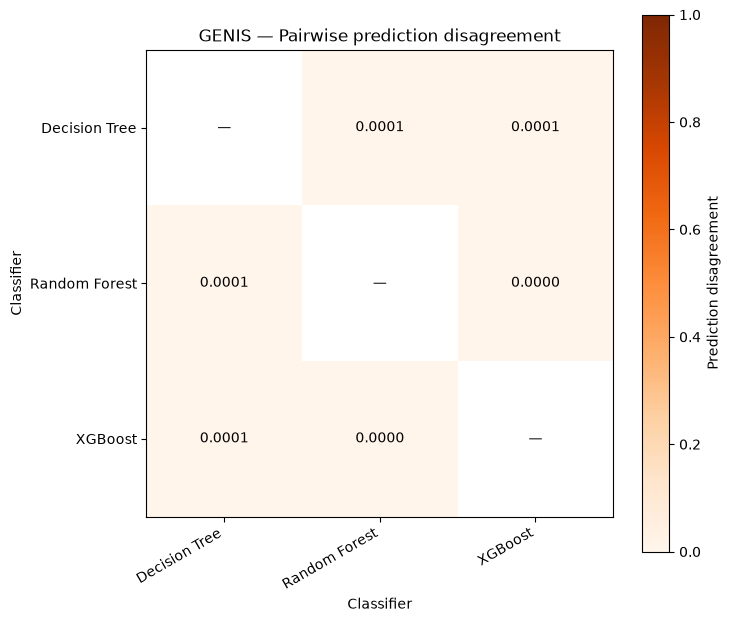

In [9]:
# ============================================================================
# Pairwise prediction disagreement heatmap
# ============================================================================

figure = plot_committee_prediction_disagreement_heatmap(
    diversity_table=GENIS_committee_statistics.diversity_table,
    title=f"{DATASET_NAME} — Pairwise prediction disagreement",
)

display(figure)
plt.close(figure)


## Committee correction behavior

These persisted statistics show cases where a committee corrects an
error made by all three components, cases where it is incorrect despite
all components being correct, and cases where it is correct while at
least one component is incorrect.


In [10]:
# ============================================================================
# Committee correction behavior
# ============================================================================

display_committee_statistics(
    GENIS_committee_statistics,
    show_configuration=False,
    show_performance=False,
    show_comparison=False,
    show_diversity=False,
    show_correction=True,
)


,Strategy,Corrected (all components wrong),Incorrect (all components correct),Correct (≥1 component wrong)
0,Hard Voting,0.00000 ± 0.00000,0.00000 ± 0.00000,3.33333 ± 1.52753
1,Weighted Hard Voting,0.00000 ± 0.00000,0.00000 ± 0.00000,3.33333 ± 1.52753
2,Soft Voting,0.00000 ± 0.00000,0.00000 ± 0.00000,3.00000 ± 1.00000
3,Weighted Soft Voting,0.00000 ± 0.00000,0.00000 ± 0.00000,3.00000 ± 1.00000


## Interpretation note

The committee strategies are predefined and all are reported. No committee
strategy is selected using the frozen test results.

For the weighted strategies, the only learned quantities are the component
weights derived from validation Macro F1 before the test evaluation. The
diversity and correction displays use the corresponding persisted committee
statistics generated by the pipeline.
